# ARC-AGI-3 - Seeded Paired Duck Evaluation

**EXP-DUCK-015 A:** control without tn36 helper.

Both notebooks use the same per-game request seeds. This isolates the tn36 helper from unrelated LLM sampling changes.


# Tufa Labs ARC3 submission

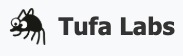

**Note**: this notebook is a more readable version of the notebook that scored our milestone-winning 1.21; unfortunately, we haven't had the same lucky result with this one. The original one is also shared here, but using it is not recommended: https://www.kaggle.com/code/jeroencottaar/taaf-duck-harness-kaggle

**Note**: if you make a copy of this notebook, you will have to manually select the proper GPU (RTX Pro 6000).

Link to writeup explaining what's going on here: https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3/discussion/717133

Link to Machine Learning Street Talk interview by Tim Scarfe about this duck harness: https://x.com/MLStreetTalk/status/2072326433922297975?s=20

This notebook executes the ARC-AGI-3 solver written by the Tufa Labs team; in alphabetical order: Harold Bessis, Jeroen Cottaar, Isaiah Pressman, Andries Smit, Michal Tesnar, and Stefano Viel.

You will only find infrastructure and diagnostics in this notebook; the actual solver code is in an attached dataset. See our writeup on the competition forum to learn more about that the solver actually does.

It installs the ARC runtime from the competition wheelhouse, makes the bundled source
snapshot importable, runs any solver setup commands, loads the pickled benchmark, plays the
competition games, and writes results to `/kaggle/working`. Diagnostics are minimised during
a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) and kept full otherwise.

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [ ]:
# 2026-07-04 preflight: verify Kaggle input mounts before running the public Duck harness.
from pathlib import Path
import os, json, sys

print("Python:", sys.version)
print("KAGGLE_IS_COMPETITION_RERUN:", os.environ.get("KAGGLE_IS_COMPETITION_RERUN"))
print("Kaggle input exists:", Path("/kaggle/input").exists())
print("Kaggle working exists:", Path("/kaggle/working").exists())

expected_hint_paths = [
    "/kaggle/input/competitions/arc-prize-2026-arc-agi-3",
    "/kaggle/input/taaf-kaggle-source-share",
    "/kaggle/input/arc3-vllm-h100-wheelhouse-v3",
    "/kaggle/input/vrfai-qwen3-6-27b-fp8-hf-snapshot",
]

for p in expected_hint_paths:
    path = Path(p)
    print(f"{p}: {'FOUND' if path.exists() else 'not found / maybe mounted elsewhere'}")

print("\nTop-level /kaggle/input entries:")
if Path("/kaggle/input").exists():
    for child in sorted(Path("/kaggle/input").iterdir()):
        print(" -", child)
else:
    print("Not running on Kaggle, or /kaggle/input is unavailable.")


In [ ]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# In submission, disable the periodic JSON/HTML diagnostics writes and per-frame logging.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1" if TRUE_SUBMISSION else "0"
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [ ]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [ ]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
DATASET_SOURCES = ["jeroencottaar/taaf-kaggle-source-share", "driessmit1/arc3-vllm-h100-wheelhouse-v3", "driessmit1/vrfai-qwen3-6-27b-fp8-hf-snapshot"]
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands — installing wheels, fetching model weights, and so on.

In [ ]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
env = _command_env()
for command in json.loads((BUNDLE_DIR / "setup_commands.json").read_text()):
    print(f"taaf.kaggle: setup command: {command}", flush=True)
    subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
    # Re-read in case the command persisted new env keys.
    env = _command_env()
    os.environ.update(env)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

## 4B. Patch controlled stall policy into the mounted source

Copy the `ARC3-Inference` source bundle into `/kaggle/working`, patch the solver adapter, and prepend that patched source before unpickling the benchmark. This keeps the original Kaggle input read-only and makes the change explicit in notebook output.


In [ ]:
# Controlled stall-policy source patch.
# This edits only the copied source in /kaggle/working, not the read-only Kaggle input.
import shutil

PATCH_ROOT = WORKING_DIR / "duck_controlled_stall_source"
PATCH_REPO = PATCH_ROOT / "ARC3-Inference"
ORIGINAL_REPO = BUNDLE_DIR / "src" / "ARC3-Inference"

if PATCH_REPO.exists():
    shutil.rmtree(PATCH_REPO)
PATCH_ROOT.mkdir(parents=True, exist_ok=True)
shutil.copytree(ORIGINAL_REPO, PATCH_REPO)

solver_py = PATCH_REPO / "inference" / "framework" / "solver.py"
text = solver_py.read_text(encoding="utf-8")

marker = "    def should_stop(self) -> bool:\n"
insert = '''    def _controlled_stall_policy(self) -> dict[str, Any]:
        policy = getattr(self.solver, "controlled_stall_policy", None)
        if not isinstance(policy, dict) or not policy.get("enabled"):
            return {}
        target_ids = policy.get("target_game_ids") or []
        if target_ids:
            run = self.game.game_run
            game_id = run.game_id if run is not None else str(self.game_index)
            if game_id not in set(str(item) for item in target_ids):
                return {}
        return policy

    def _controlled_stall_reason(self) -> str | None:
        policy = self._controlled_stall_policy()
        if not policy:
            return None
        min_actions = int(policy.get("min_actions", 0) or 0)
        if self.action_count < min_actions:
            return None
        no_progress_limit = int(policy.get("max_no_level_progress_actions", 0) or 0)
        if no_progress_limit > 0 and int(getattr(self, "_stall_no_level_progress_actions", 0)) >= no_progress_limit:
            return f"no_level_progress_actions>={no_progress_limit}"
        zero_limit = int(policy.get("max_consecutive_zero_token_actions", 0) or 0)
        if zero_limit > 0 and int(getattr(self, "_stall_consecutive_zero_token_actions", 0)) >= zero_limit:
            return f"consecutive_zero_token_actions>={zero_limit}"
        return None

    def _update_controlled_stall_counters(self, payload: dict[str, Any], generated_tokens: int) -> None:
        made_level_progress = bool(payload.get("level_completed")) or bool(payload.get("run_complete"))
        try:
            made_level_progress = made_level_progress or float(payload.get("reward", 0.0) or 0.0) > 0.0
        except (TypeError, ValueError):
            pass
        if made_level_progress:
            self._stall_no_level_progress_actions = 0
        else:
            self._stall_no_level_progress_actions = int(getattr(self, "_stall_no_level_progress_actions", 0)) + 1
        if int(generated_tokens or 0) == 0:
            self._stall_consecutive_zero_token_actions = int(getattr(self, "_stall_consecutive_zero_token_actions", 0)) + 1
        else:
            self._stall_consecutive_zero_token_actions = 0

'''
if insert.strip() not in text:
    text = text.replace(marker, insert + marker)

ft09_insert = '    def _ft09_level3_helper_policy(self) -> dict[str, Any]:\n        policy = getattr(self.solver, "ft09_level3_helper_policy", None)\n        if not isinstance(policy, dict) or not policy.get("enabled"):\n            return {}\n        run = self.game.game_run\n        game_id = run.game_id if run is not None else str(self.game_index)\n        if str(policy.get("game_id", "ft09-0d8bbf25")) != game_id:\n            return {}\n        return policy\n\n    def _ft09_level3_candidate_targets(self) -> list[tuple[str, dict[tuple[int, int], int]]]:\n        board = _grid_from_state(self.game.current_state)\n        if not board or len(board) < 64 or len(board[0]) < 64:\n            return []\n        red = 8\n        orange = 12\n        white = 0\n        gray = 2\n        regular_cells = [\n            (6, 22), (6, 30), (6, 38),\n            (14, 22), (14, 38),\n            (22, 14), (22, 22), (22, 30), (22, 38), (22, 46),\n            (30, 14), (30, 30), (30, 46),\n            (38, 14), (38, 22), (38, 30), (38, 38), (38, 46),\n            (46, 22), (46, 38),\n            (54, 22), (54, 30), (54, 38),\n        ]\n        special_cells = [(14, 30), (30, 22), (30, 38), (46, 30)]\n        regular = set(regular_cells)\n\n        def mask_values(special: tuple[int, int]) -> dict[tuple[int, int], int]:\n            row, col = special\n            return {\n                (dr, dc): int(board[row + dr * 2][col + dc * 2])\n                for dr in (-1, 0, 1)\n                for dc in (-1, 0, 1)\n            }\n\n        def target_votes(white_policy: str) -> dict[tuple[int, int], list[int]]:\n            votes = {cell: [] for cell in regular_cells}\n            for special in special_cells:\n                center_color = int(board[special[0]][special[1]])\n                other_color = red if center_color == orange else orange\n                for (dr, dc), value in mask_values(special).items():\n                    if (dr, dc) == (0, 0):\n                        continue\n                    target_cell = (special[0] + dr * 8, special[1] + dc * 8)\n                    if target_cell not in regular:\n                        continue\n                    if white_policy == "white_is_orange":\n                        color = orange if value == white else red\n                    elif white_policy == "white_is_center":\n                        color = center_color if value == white else other_color\n                    elif white_policy == "gray_is_center":\n                        color = center_color if value == gray else other_color\n                    else:\n                        color = red\n                    votes[target_cell].append(color)\n            return votes\n\n        def combine(values: list[int], rule: str) -> int:\n            if not values:\n                return red\n            if rule == "orange_wins":\n                return orange if orange in values else red\n            if rule == "red_wins":\n                return red if red in values else orange\n            if rule == "majority":\n                oranges = sum(1 for value in values if value == orange)\n                reds = sum(1 for value in values if value == red)\n                return orange if oranges >= reds else red\n            if rule == "parity":\n                return orange if sum(1 for value in values if value == orange) % 2 else red\n            if rule == "last":\n                return values[-1]\n            return red\n\n        candidates: list[tuple[str, dict[tuple[int, int], int]]] = []\n        seen: set[tuple[tuple[int, int], ...]] = set()\n        for white_policy in ("gray_is_center", "white_is_orange", "white_is_center"):\n            votes = target_votes(white_policy)\n            for rule in ("parity", "orange_wins", "majority", "red_wins", "last"):\n                target = {cell: combine(votes[cell], rule) for cell in regular_cells}\n                orange_cells = tuple(cell for cell in regular_cells if target[cell] == orange)\n                if orange_cells in seen:\n                    continue\n                seen.add(orange_cells)\n                candidates.append((f"{white_policy}+{rule}", target))\n        candidates.sort(key=lambda item: (sum(1 for color in item[1].values() if color == orange), item[0]))\n        return candidates\n\n    def _try_ft09_level3_helper(self) -> bool:\n        policy = self._ft09_level3_helper_policy()\n        if not policy:\n            return False\n        if _level_number(self.game) != int(policy.get("level", 3) or 3):\n            return False\n        if bool(getattr(self, "_ft09_level3_helper_tried", False)):\n            return False\n        self._ft09_level3_helper_tried = True\n        max_candidates = int(policy.get("max_candidates", 6) or 6)\n        candidates = self._ft09_level3_candidate_targets()[:max_candidates]\n        if not candidates:\n            return False\n        executed_total = 0\n        for candidate_name, target in candidates:\n            current = _grid_from_state(self.game.current_state)\n            requested_cells = [cell for cell, target_color in target.items() if int(current[cell[0]][cell[1]]) != int(target_color)]\n            if not requested_cells:\n                continue\n            batch_size = len(requested_cells)\n            for batch_index, (row, col) in enumerate(requested_cells, start=1):\n                if self.should_stop():\n                    return True\n                action = arcengine.ActionInput(id=arcengine.GameAction.ACTION6, data={"x": col, "y": row})\n                payload = self._execute_action(\n                    action,\n                    batch_index=batch_index,\n                    batch_size=batch_size,\n                    generated_tokens=0,\n                    flush_viewer_payload=False,\n                )\n                executed_total += 1\n                if payload.get("level_completed") or payload.get("run_complete") or payload.get("game_over"):\n                    run = self.game.game_run\n                    if run is not None:\n                        prefix = f"ft09_helper={candidate_name}; helper_actions={executed_total}"\n                        run.solver_note = f"{prefix}; {run.solver_note}" if run.solver_note else prefix\n                    self.write_viewer_payload()\n                    return True\n            self.write_viewer_payload()\n        if executed_total > 0:\n            run = self.game.game_run\n            if run is not None:\n                prefix = f"ft09_mask_cycle_exhausted; helper_actions={executed_total}"\n                run.solver_note = f"{prefix}; {run.solver_note}" if run.solver_note else prefix\n            if bool(policy.get("stop_after_attempt", False)):\n                self._ft09_overlap_stop = True\n        return executed_total > 0\n\n'
if ft09_insert.strip() not in text:
    text = text.replace(marker, ft09_insert + marker)

ft09_replay_insert = '    def _ft09_replay_prefix_policy(self) -> dict[str, Any]:\n        policy = getattr(self.solver, "ft09_replay_prefix_policy", None)\n        if not isinstance(policy, dict) or not policy.get("enabled"):\n            return {}\n        run = self.game.game_run\n        game_id = run.game_id if run is not None else str(self.game_index)\n        if str(policy.get("game_id", "ft09-0d8bbf25")) != game_id:\n            return {}\n        return policy\n\n    def _try_ft09_replay_prefix(self) -> bool:\n        policy = self._ft09_replay_prefix_policy()\n        if not policy:\n            return False\n        if bool(getattr(self, "_ft09_replay_prefix_tried", False)):\n            return False\n        if self.action_count != int(policy.get("start_action_count", 0) or 0):\n            return False\n        if _level_number(self.game) != int(policy.get("start_level", 1) or 1):\n            return False\n        self._ft09_replay_prefix_tried = True\n        actions = list(policy.get("actions") or [])\n        target_level = int(policy.get("target_level", 4) or 4)\n        executed_total = 0\n        for batch_index, item in enumerate(actions, start=1):\n            if self.should_stop():\n                return True\n            data = dict(item.get("data") or {})\n            action_id = str(item.get("id", "ACTION6"))\n            game_action = getattr(arcengine.GameAction, action_id)\n            action = arcengine.ActionInput(id=game_action, data=data)\n            payload = self._execute_action(\n                action,\n                batch_index=batch_index,\n                batch_size=len(actions),\n                generated_tokens=0,\n                flush_viewer_payload=False,\n            )\n            executed_total += 1\n            if payload.get("run_complete") or payload.get("game_over"):\n                break\n        run = self.game.game_run\n        if run is not None:\n            reached_level = _level_number(self.game)\n            prefix = f"ft09_prefix_replay_actions={executed_total}; reached_level={reached_level}; target_level={target_level}"\n            run.solver_note = f"{prefix}; {run.solver_note}" if run.solver_note else prefix\n        self.write_viewer_payload()\n        return True\n\n'
if ft09_replay_insert.strip() not in text:
    text = text.replace(marker, ft09_replay_insert + marker)

ft09_cycle_insert = '    def _ft09_mask_cycle_helper_policy(self) -> dict[str, Any]:\n        policy = getattr(self.solver, "ft09_mask_cycle_helper_policy", None)\n        if not isinstance(policy, dict) or not policy.get("enabled"):\n            return {}\n        run = self.game.game_run\n        game_id = run.game_id if run is not None else str(self.game_index)\n        if str(policy.get("game_id", "ft09-0d8bbf25")) != game_id:\n            return {}\n        return policy\n\n    def _ft09_cycle_distance(self, current: int, target: int, cycle: list[int]) -> int:\n        if current == target:\n            return 0\n        if current not in cycle or target not in cycle:\n            return 0\n        i = cycle.index(current)\n        for steps in range(1, len(cycle) + 1):\n            if cycle[(i + steps) % len(cycle)] == target:\n                return steps\n        return 0\n\n    def _ft09_level4_cycle_candidates(self) -> list[tuple[str, dict[tuple[int, int], int]]]:\n        board = _grid_from_state(self.game.current_state)\n        if not board or len(board) < 64 or len(board[0]) < 64:\n            return []\n        blue = 9\n        red = 8\n        orange = 12\n        white = 0\n        gray = 2\n        normal_cells = [\n            (16, 14), (16, 22), (16, 30), (16, 38), (16, 46),\n            (24, 14), (24, 30), (24, 46),\n            (32, 14), (32, 22), (32, 30), (32, 38), (32, 46),\n            (40, 22), (40, 38),\n            (48, 22), (48, 30), (48, 38),\n        ]\n        special_cells = [(24, 22), (24, 38), (40, 30)]\n        normal = set(normal_cells)\n        cycle = [blue, red, orange]\n        if not all(int(board[r][c]) in cycle for r, c in normal_cells):\n            return []\n        if not all(int(board[r][c]) in cycle for r, c in special_cells):\n            return []\n\n        def mask_values(special: tuple[int, int]) -> dict[tuple[int, int], int]:\n            row, col = special\n            return {\n                (dr, dc): int(board[row + dr * 2][col + dc * 2])\n                for dr in (-1, 0, 1)\n                for dc in (-1, 0, 1)\n            }\n\n        def votes_for(policy_name: str) -> dict[tuple[int, int], list[int]]:\n            votes = {cell: [] for cell in normal_cells}\n            palette_by_index = [blue, red, orange]\n            for special_index, special in enumerate(special_cells):\n                center_color = int(board[special[0]][special[1]])\n                other_colors = [color for color in cycle if color != center_color]\n                for (dr, dc), value in mask_values(special).items():\n                    if (dr, dc) == (0, 0):\n                        continue\n                    target_cell = (special[0] + dr * 8, special[1] + dc * 8)\n                    if target_cell not in normal:\n                        continue\n                    if policy_name == "white_is_center":\n                        color = center_color if value == white else other_colors[0]\n                    elif policy_name == "gray_is_center":\n                        color = center_color if value == gray else other_colors[0]\n                    elif policy_name == "white_is_palette":\n                        color = palette_by_index[special_index % len(palette_by_index)] if value == white else center_color\n                    elif policy_name == "gray_is_palette":\n                        color = palette_by_index[special_index % len(palette_by_index)] if value == gray else center_color\n                    elif policy_name == "white_cycles_from_center":\n                        offset = 1 if value == white else 2 if value == gray else 0\n                        color = cycle[(cycle.index(center_color) + offset) % len(cycle)]\n                    else:\n                        color = center_color\n                    votes[target_cell].append(color)\n            return votes\n\n        def combine(values: list[int], rule: str) -> int:\n            if not values:\n                return blue\n            if rule == "last":\n                return values[-1]\n            if rule == "majority":\n                counts = {color: sum(1 for value in values if value == color) for color in cycle}\n                return max(cycle, key=lambda color: (counts[color], -cycle.index(color)))\n            if rule == "parity":\n                index_sum = sum(cycle.index(value) for value in values if value in cycle)\n                return cycle[index_sum % len(cycle)]\n            if rule.endswith("_wins"):\n                winner_name = rule.removesuffix("_wins")\n                winner = {"blue": blue, "red": red, "orange": orange}.get(winner_name, blue)\n                return winner if winner in values else values[-1]\n            return values[-1]\n\n        candidates: list[tuple[str, dict[tuple[int, int], int]]] = []\n        seen: set[tuple[tuple[int, int], ...]] = set()\n        policies = ["white_is_center", "gray_is_center", "white_is_palette", "gray_is_palette", "white_cycles_from_center"]\n        rules = ["parity", "majority", "blue_wins", "red_wins", "orange_wins", "last"]\n        for policy_name in policies:\n            votes = votes_for(policy_name)\n            for rule in rules:\n                target = {cell: combine(votes[cell], rule) for cell in normal_cells}\n                signature = tuple((cell, target[cell]) for cell in normal_cells)\n                if signature in seen:\n                    continue\n                seen.add(signature)\n                candidates.append((f"level4:{policy_name}+{rule}", target))\n        candidates.sort(key=lambda item: (sum(self._ft09_cycle_distance(int(board[r][c]), color, cycle) for (r, c), color in item[1].items()), item[0]))\n        return candidates\n\n    def _try_ft09_mask_cycle_helper(self) -> bool:\n        policy = self._ft09_mask_cycle_helper_policy()\n        if not policy:\n            return False\n        level = _level_number(self.game)\n        target_levels = set(int(item) for item in policy.get("levels", [4]))\n        if level not in target_levels:\n            return False\n        tried_key = f"_ft09_mask_cycle_helper_tried_level_{level}"\n        if bool(getattr(self, tried_key, False)):\n            return False\n        setattr(self, tried_key, True)\n        candidates = self._ft09_level4_cycle_candidates()[: int(policy.get("max_candidates", 8) or 8)]\n        if not candidates:\n            if bool(policy.get("stop_after_attempt", False)):\n                run = self.game.game_run\n                if run is not None:\n                    prefix = "ft09_mask_cycle_no_candidates"\n                    run.solver_note = f"{prefix}; {run.solver_note}" if run.solver_note else prefix\n                self._ft09_overlap_stop = True\n            return False\n        board = _grid_from_state(self.game.current_state)\n        cycle = [9, 8, 12]\n        executed_total = 0\n        for candidate_name, target in candidates:\n            current = _grid_from_state(self.game.current_state)\n            requested: list[tuple[int, int]] = []\n            for (row, col), target_color in target.items():\n                steps = self._ft09_cycle_distance(int(current[row][col]), int(target_color), cycle)\n                requested.extend([(row, col)] * steps)\n            if not requested:\n                continue\n            batch_size = len(requested)\n            for batch_index, (row, col) in enumerate(requested, start=1):\n                if self.should_stop():\n                    return True\n                action = arcengine.ActionInput(id=arcengine.GameAction.ACTION6, data={"x": col, "y": row})\n                payload = self._execute_action(\n                    action,\n                    batch_index=batch_index,\n                    batch_size=batch_size,\n                    generated_tokens=0,\n                    flush_viewer_payload=False,\n                )\n                executed_total += 1\n                if payload.get("level_completed") or payload.get("run_complete") or payload.get("game_over"):\n                    run = self.game.game_run\n                    if run is not None:\n                        prefix = f"ft09_mask_cycle={candidate_name}; helper_actions={executed_total}"\n                        run.solver_note = f"{prefix}; {run.solver_note}" if run.solver_note else prefix\n                    self.write_viewer_payload()\n                    return True\n            self.write_viewer_payload()\n        return executed_total > 0\n\n'
if ft09_cycle_insert.strip() not in text:
    text = text.replace(marker, ft09_cycle_insert + marker)

old_should_stop = '''        if (
            self.solver.max_actions_per_game is not None
            and self.action_count >= self.solver.max_actions_per_game
        ):
            return True
        return False
'''
new_should_stop = '''        if (
            self.solver.max_actions_per_game is not None
            and self.action_count >= self.solver.max_actions_per_game
        ):
            return True
        controlled_stall_reason = self._controlled_stall_reason()
        if controlled_stall_reason is not None:
            if run.solver_note is None:
                run.solver_note = f"controlled_stall={controlled_stall_reason}; tokens={_analyzer_reported_tokens(self.analyzer)}"
            return True
        return False
'''
if old_should_stop not in text:
    raise RuntimeError("Could not patch should_stop(); source shape changed.")
text = text.replace(old_should_stop, new_should_stop)

old_execute = '''        self._append_action_viewer_event(payload, current_frame)
        if flush_viewer_payload:
            self.write_viewer_payload()
        return payload
'''
new_execute = '''        self._update_controlled_stall_counters(payload, generated_tokens)
        self._append_action_viewer_event(payload, current_frame)
        if flush_viewer_payload:
            self.write_viewer_payload()
        return payload
'''
if old_execute not in text:
    raise RuntimeError("Could not patch _execute_action(); source shape changed.")
text = text.replace(old_execute, new_execute)

old_play_loop = '                if (\n                    _is_engine_game_over(self.game)\n                    and self.last_engine_action != "RESET"\n                ):\n                    self._execute_auto_reset()\n                    continue\n\n                if retry_analysis_step is None:\n'
new_play_loop = '                if (\n                    _is_engine_game_over(self.game)\n                    and self.last_engine_action != "RESET"\n                ):\n                    self._execute_auto_reset()\n                    continue\n\n                if self._try_ft09_level3_helper():\n                    continue\n\n                if retry_analysis_step is None:\n'
if old_play_loop not in text:
    raise RuntimeError("Could not patch play loop for ft09 helper; source shape changed.")
text = text.replace(old_play_loop, new_play_loop)

old_cycle_play_hook = '                if self._try_ft09_level3_helper():\n                    continue\n\n                if retry_analysis_step is None:\n'
new_cycle_play_hook = '                if self._try_ft09_replay_prefix():\n                    continue\n\n                if self._try_ft09_level3_helper():\n                    continue\n\n                if self._try_ft09_mask_cycle_helper():\n                    continue\n\n                if retry_analysis_step is None:\n'
if old_cycle_play_hook not in text:
    raise RuntimeError("Could not patch play loop for ft09 mask-cycle helper; source shape changed.")
text = text.replace(old_cycle_play_hook, new_cycle_play_hook)

# EXP-DUCK-009: keep the confirmed target but stop only this game runner.

ft09_overlap_helper = '    def _try_ft09_mask_cycle_helper(self) -> bool:\n        policy = self._ft09_mask_cycle_helper_policy()\n        if not policy:\n            return False\n        level = _level_number(self.game)\n        target_levels = set(int(item) for item in policy.get("levels", [4]))\n        if level not in target_levels:\n            return False\n        tried_key = f"_ft09_overlap_helper_tried_level_{level}"\n        if bool(getattr(self, tried_key, False)):\n            return False\n        setattr(self, tried_key, True)\n\n        board = _grid_from_state(self.game.current_state)\n        normal_cells = [\n            (16, 14), (16, 22), (16, 30), (16, 38), (16, 46),\n            (24, 14), (24, 30), (24, 46),\n            (32, 14), (32, 22), (32, 30), (32, 38), (32, 46),\n            (40, 22), (40, 38),\n            (48, 22), (48, 30), (48, 38),\n        ]\n        special_cells = [(24, 22), (24, 38), (40, 30)]\n        cycle = [9, 8, 12]\n        target_string = str(policy.get("target_centers", "RORbRRRRRORRbRROOO"))\n        color_by_name = {"b": 9, "R": 8, "O": 12}\n        expected_masks = {\n            (24, 22): (12, ("gWg", "gOg", "gWg")),\n            (24, 38): (9, ("gWg", "gbg", "ggW")),\n            (40, 30): (12, ("Wgg", "gOg", "WWW")),\n        }\n\n        def mask_signature(special: tuple[int, int]) -> tuple[str, str, str]:\n            names = {0: "W", 2: "g", 8: "R", 9: "b", 12: "O"}\n            row, col = special\n            return tuple(\n                "".join(names.get(int(board[row + dr * 2][col + dc * 2]), "?") for dc in (-1, 0, 1))\n                for dr in (-1, 0, 1)\n            )\n\n        signature_ok = (\n            bool(board)\n            and len(board) >= 64\n            and len(board[0]) >= 64\n            and len(target_string) == len(normal_cells)\n            and set(target_string) <= set(color_by_name)\n            and all(int(board[row][col]) in cycle for row, col in normal_cells)\n            and all(\n                int(board[row][col]) == expected_masks[(row, col)][0]\n                and mask_signature((row, col)) == expected_masks[(row, col)][1]\n                for row, col in special_cells\n            )\n        )\n        if not signature_ok:\n            run = self.game.game_run\n            if run is not None:\n                prefix = "ft09_overlap_signature_mismatch"\n                run.solver_note = f"{prefix}; {run.solver_note}" if run.solver_note else prefix\n            if bool(policy.get("stop_after_attempt", True)):\n                self._ft09_overlap_stop = True\n            return True\n\n        target = {\n            cell: color_by_name[target_name]\n            for cell, target_name in zip(normal_cells, target_string)\n        }\n        requested: list[tuple[int, int]] = []\n        for (row, col), target_color in target.items():\n            steps = self._ft09_cycle_distance(int(board[row][col]), target_color, cycle)\n            requested.extend([(row, col)] * steps)\n\n        planned_actions = len(requested)\n        executed_actions = 0\n        solved = False\n        stop_reason = "target_exhausted"\n        for batch_index, (row, col) in enumerate(requested, start=1):\n            if self.should_stop():\n                stop_reason = "should_stop"\n                break\n            action = arcengine.ActionInput(\n                id=arcengine.GameAction.ACTION6,\n                data={"x": col, "y": row},\n            )\n            payload = self._execute_action(\n                action,\n                batch_index=batch_index,\n                batch_size=planned_actions,\n                generated_tokens=0,\n                flush_viewer_payload=False,\n            )\n            executed_actions += 1\n            if payload.get("level_completed") or payload.get("run_complete") or payload.get("game_over"):\n                solved = bool(payload.get("level_completed"))\n                stop_reason = "level_completed" if solved else "game_over_or_run_complete"\n                break\n\n        run = self.game.game_run\n        if run is not None:\n            prefix = (\n                f"ft09_overlap_target={target_string}; planned={planned_actions}; "\n                f"executed={executed_actions}; solved={solved}; stop={stop_reason}"\n            )\n            run.solver_note = f"{prefix}; {run.solver_note}" if run.solver_note else prefix\n        if bool(policy.get("stop_after_attempt", True)):\n            self._ft09_overlap_stop = True\n        self.write_viewer_payload()\n        return True\n\n'

start = text.index('    def _try_ft09_mask_cycle_helper')
end = text.index('    def should_stop', start)
text = text[:start] + ft09_overlap_helper + text[end:]

old_should_stop = "    def should_stop(self) -> bool:\n        run = self.game.game_run\n"
new_should_stop = "    def should_stop(self) -> bool:\n        if bool(getattr(self, '_ft09_overlap_stop', False)):\n            return True\n        run = self.game.game_run\n"
if old_should_stop not in text:
    raise RuntimeError("Could not add per-game ft09 stop flag; source shape changed.")
text = text.replace(old_should_stop, new_should_stop, 1)

solver_py.write_text(text, encoding="utf-8")

# Prepend patched source before loading benchmark_initial.pkl, whose solver class lives in inference.framework.solver.
patched_source_root = str(PATCH_REPO)
if patched_source_root not in sys.path:
    sys.path.insert(0, patched_source_root)
for module_name in ["inference.framework.solver"]:
    sys.modules.pop(module_name, None)

print("Patched solver source:", solver_py)
print("Prepended patched source root:", patched_source_root)


# EXP-DUCK-015: scheduling-independent per-game request seeds.
seed_module_py = PATCH_REPO / "inference" / "agent" / "deterministic_request_seed.py"
seed_module_py.write_text('"""Stable per-game model-request seeds for paired Duck experiments."""\n\nfrom __future__ import annotations\n\nimport hashlib\n\n\nMAX_SEED = 2_147_483_647\n\n\ndef stable_request_seed(namespace: str, request_index: int, salt: str) -> int:\n    """Return a stable non-negative seed independent of process scheduling."""\n    payload = f"{salt}:{namespace}:{int(request_index)}".encode("utf-8")\n    digest = hashlib.sha256(payload).digest()\n    return int.from_bytes(digest[:8], "big") % MAX_SEED\n\n\nclass RequestSeedSequence:\n    """Issue one deterministic seed per request for a single game session."""\n\n    def __init__(\n        self,\n        namespace: str | None,\n        *,\n        salt: str,\n        fallback_seed: int = -1,\n    ) -> None:\n        self.namespace = str(namespace or "").strip()\n        self.salt = str(salt)\n        self.fallback_seed = int(fallback_seed)\n        self.request_index = 0\n\n    def next_seed(self) -> int:\n        if not self.namespace:\n            return self.fallback_seed\n        seed = stable_request_seed(self.namespace, self.request_index, self.salt)\n        self.request_index += 1\n        return seed\n', encoding="utf-8")

tool_agent_py = PATCH_REPO / "inference" / "agent" / "tool_agent.py"
tool_text = tool_agent_py.read_text(encoding="utf-8")
seed_import = "from inference.agent.deterministic_request_seed import RequestSeedSequence\n"
import_anchor = "from inference.agent.action_names import to_engine_action, to_model_action\n"
if seed_import not in tool_text:
    if import_anchor not in tool_text:
        raise RuntimeError("Could not add deterministic seed import.")
    tool_text = tool_text.replace(import_anchor, seed_import + import_anchor, 1)

signature_anchor = "        provider: str | None = None,\n    ) -> None:"
signature_replacement = "        provider: str | None = None,\n        seed_namespace: str | None = None,\n    ) -> None:"
if signature_anchor not in tool_text:
    raise RuntimeError("Could not add ToolAgent seed namespace.")
tool_text = tool_text.replace(signature_anchor, signature_replacement, 1)

state_anchor = "        self._save_request_logs = bool(save_request_logs)\n"
state_replacement = state_anchor + '''        self._request_seed_sequence = RequestSeedSequence(
            seed_namespace,
            salt=os.environ.get("LOCAL_ANALYZER_SEED_SALT", "exp-duck-paired-v1"),
            fallback_seed=_LOCAL_ANALYZER_SEED,
        )
'''
if state_anchor not in tool_text:
    raise RuntimeError("Could not initialize deterministic request seeds.")
tool_text = tool_text.replace(state_anchor, state_replacement, 1)

seed_anchor = "            seed=_LOCAL_ANALYZER_SEED,\n"
seed_replacement = "            seed=self._request_seed_sequence.next_seed(),\n"
if seed_anchor not in tool_text:
    raise RuntimeError("Could not route request seed through the per-game sequence.")
tool_text = tool_text.replace(seed_anchor, seed_replacement, 1)
tool_agent_py.write_text(tool_text, encoding="utf-8")

solver_text = solver_py.read_text(encoding="utf-8")
solver_anchor = '            provider="vllm" if local_server is not None else None,\n        )'
solver_replacement = '''            provider="vllm" if local_server is not None else None,
            seed_namespace=(
                game.game_run.game_id
                if game.game_run is not None
                else str(index)
            ),
        )'''
if solver_anchor not in solver_text:
    raise RuntimeError("Could not pass the game id to ToolAgent.")
solver_text = solver_text.replace(solver_anchor, solver_replacement, 1)
solver_py.write_text(solver_text, encoding="utf-8")

for module_name in [
    "inference.agent.deterministic_request_seed",
    "inference.agent.tool_agent",
    "inference.framework.solver",
]:
    sys.modules.pop(module_name, None)
print("Enabled deterministic per-game request seeds.")


## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [ ]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Customization hook

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts — the safe place
for one-off experiments once the deployed bundle has loaded.

In [ ]:
os.environ["LOCAL_ANALYZER_SEED_SALT"] = 'exp-duck-015-paired-v1'
# EXP-DUCK-009 controlled full evaluation.
# Run every baseline game once; helper policies remain gated to ft09 only.

DUCK_REPRO_LABEL = "duck-seeded-pair-control-20260722"
LIMIT_TO_GAME_IDS = ['ft09-0d8bbf25', 'tn36-ef4dde99', 'ar25-0c556536', 'cd82-fb555c5d', 'cn04-2fe56bfb', 'r11l-495a7899', 'vc33-5430563c', 'm0r0-492f87ba']
MAX_GAMES_FOR_DEBUG = None

CONTROLLED_STALL_POLICY = {
    "enabled": False,
    "target_game_ids": ["ft09-0d8bbf25"],
    # Do not stop before the solver has had a fair chance to infer the mechanic.
    "min_actions": 24,
    # Stop after many actions without a level transition. This attacks tn36/sc25/tr87 waste.
    "max_no_level_progress_actions": 180,
    # Stop after long consecutive zero-token action runs. This catches batched/repeated execution loops.
    "max_consecutive_zero_token_actions": None,
}

FT09_REPLAY_PREFIX_POLICY = {
    "enabled": True,
    "game_id": "ft09-0d8bbf25",
    "start_level": 1,
    "start_action_count": 0,
    "target_level": 4,
    "actions": [{"id": "ACTION6","data": {"x": 46,"y": 46}},{"id": "ACTION6","data": {"x": 14,"y": 12}},{"id": "ACTION6","data": {"x": 14,"y": 4}},{"id": "ACTION6","data": {"x": 40,"y": 32}},{"id": "ACTION6","data": {"x": 34,"y": 34}},{"id": "ACTION6","data": {"x": 38,"y": 38}},{"id": "ACTION6","data": {"x": 38,"y": 46}},{"id": "ACTION6","data": {"x": 54,"y": 46}},{"id": "ACTION6","data": {"x": 38,"y": 54}},{"id": "ACTION6","data": {"x": 23,"y": 17}},{"id": "ACTION6","data": {"x": 23,"y": 25}},{"id": "ACTION6","data": {"x": 39,"y": 25}},{"id": "ACTION6","data": {"x": 23,"y": 33}},{"id": "ACTION6","data": {"x": 39,"y": 33}},{"id": "ACTION6","data": {"x": 23,"y": 49}},{"id": "ACTION6","data": {"x": 31,"y": 49}},{"id": "ACTION6","data": {"x": 38,"y": 14}},{"id": "ACTION6","data": {"x": 46,"y": 22}},{"id": "ACTION6","data": {"x": 14,"y": 38}},{"id": "ACTION6","data": {"x": 38,"y": 46}},{"id": "ACTION6","data": {"x": 22,"y": 22}},{"id": "ACTION6","data": {"x": 38,"y": 22}},{"id": "ACTION6","data": {"x": 30,"y": 30}},{"id": "ACTION6","data": {"x": 22,"y": 38}},{"id": "ACTION6","data": {"x": 38,"y": 38}},{"id": "ACTION6","data": {"x": 22,"y": 6}},{"id": "ACTION6","data": {"x": 30,"y": 6}},{"id": "ACTION6","data": {"x": 38,"y": 6}},{"id": "ACTION6","data": {"x": 22,"y": 14}},{"id": "ACTION6","data": {"x": 38,"y": 14}},{"id": "ACTION6","data": {"x": 22,"y": 22}},{"id": "ACTION6","data": {"x": 38,"y": 22}},{"id": "ACTION6","data": {"x": 22,"y": 38}},{"id": "ACTION6","data": {"x": 38,"y": 38}},{"id": "ACTION6","data": {"x": 22,"y": 46}},{"id": "ACTION6","data": {"x": 38,"y": 46}},{"id": "ACTION6","data": {"x": 22,"y": 54}},{"id": "ACTION6","data": {"x": 30,"y": 54}},{"id": "ACTION6","data": {"x": 38,"y": 54}},{"id": "ACTION6","data": {"x": 14,"y": 22}},{"id": "ACTION6","data": {"x": 30,"y": 22}},{"id": "ACTION6","data": {"x": 46,"y": 22}},{"id": "ACTION6","data": {"x": 14,"y": 30}},{"id": "ACTION6","data": {"x": 30,"y": 30}},{"id": "ACTION6","data": {"x": 46,"y": 30}},{"id": "ACTION6","data": {"x": 14,"y": 38}},{"id": "ACTION6","data": {"x": 30,"y": 38}},{"id": "ACTION6","data": {"x": 46,"y": 38}}]
}

FT09_LEVEL3_HELPER_POLICY = {
    "enabled": True,
    "game_id": "ft09-0d8bbf25",
    "level": 3,
    "max_candidates": 6,
}

FT09_MASK_CYCLE_HELPER_POLICY = {
    "enabled": True,
    "game_id": "ft09-0d8bbf25",
    "levels": [4],
    "target_centers": "RORbRRRRRORRbRROOO",
    "stop_after_attempt": True,
}

try:
    bm.label = f"{getattr(bm, 'label', 'duck')}-{DUCK_REPRO_LABEL}"
    print("Benchmark label:", bm.label)
except Exception as exc:
    print("Could not set benchmark label:", repr(exc))

try:
    bm.solver.controlled_stall_policy = dict(CONTROLLED_STALL_POLICY)
    bm.solver.ft09_replay_prefix_policy = dict(FT09_REPLAY_PREFIX_POLICY)
    bm.solver.ft09_level3_helper_policy = dict(FT09_LEVEL3_HELPER_POLICY)
    bm.solver.ft09_mask_cycle_helper_policy = dict(FT09_MASK_CYCLE_HELPER_POLICY)
    print("ft09 replay prefix policy:", json.dumps({**bm.solver.ft09_replay_prefix_policy, "actions": f"{len(FT09_REPLAY_PREFIX_POLICY['actions'])} actions"}, sort_keys=True))
    print("ft09 level-3 helper policy:", json.dumps(bm.solver.ft09_level3_helper_policy, sort_keys=True))
    print("ft09 overlap helper policy:", json.dumps(bm.solver.ft09_mask_cycle_helper_policy, sort_keys=True))
    # Preserve the baseline model, prompt, action/runtime caps, and concurrency.
    print("Controlled stall policy:", json.dumps(bm.solver.controlled_stall_policy, sort_keys=True))
    print("Solver caps:", {
        "max_actions_per_game": bm.solver.max_actions_per_game,
        "max_runtime_s_per_game": bm.solver.max_runtime_s_per_game,
        "concurrency": bm.solver.concurrency,
    })
except Exception as exc:
    print("Could not configure controlled stall policy:", repr(exc))

def _game_id(g):
    for attr in ("game_id", "env_name", "name"):
        value = getattr(g, attr, None)
        if value:
            return str(value)
    return str(g)


def _apply_target_game_filter(games):
    filtered = list(games)
    original_n_games = len(filtered)
    if LIMIT_TO_GAME_IDS:
        wanted = set(LIMIT_TO_GAME_IDS)
        filtered = [g for g in filtered if _game_id(g) in wanted]
    if MAX_GAMES_FOR_DEBUG is not None:
        filtered = filtered[: int(MAX_GAMES_FOR_DEBUG)]
    if LIMIT_TO_GAME_IDS or MAX_GAMES_FOR_DEBUG is not None:
        print(f"Filtered games after game-list construction: {original_n_games} -> {len(filtered)}")
        print("Selected games:", [_game_id(g) for g in filtered])
    else:
        print("No game filtering applied.")
    return filtered


In [ ]:
# 2026-07-04 reproducibility manifest.
# This does not change the Duck harness. It only writes a small manifest to /kaggle/working.
from pathlib import Path
import json, os, time, platform

manifest = {
    "session": "2026-07-04",
    "notebook_role": "duck_public_repro_workbench",
    "run_as_competition_rerun": os.environ.get("KAGGLE_IS_COMPETITION_RERUN", ""),
    "platform": platform.platform(),
    "python": platform.python_version(),
    "time_epoch": time.time(),
    "notes": [
        "Run unchanged first.",
        "Use outputs as baseline artifact before modifying the customization hook.",
        "Do not claim improvement until validated by diagnostics or Kaggle score."
    ],
}
working = Path("/kaggle/working")
if working.exists():
    out_path = working / "arc3_duck_repro_manifest_20260704.json"
    out_path.write_text(json.dumps(manifest, indent=2, sort_keys=True) + "\n")
    print("Wrote:", out_path)
else:
    print(json.dumps(manifest, indent=2, sort_keys=True))


## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise — an interactive "Save & Run" — play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.

In [ ]:
# Build the live competition game list from the gateway's available environments.
def _competition_games():
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=os.environ["ARC_BASE_URL"],
        environments_dir="",
    )
    arcade = arc_agi.Arcade(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=spec.arc_base_url,
        environments_dir="",
    )
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError("Competition Arcade exposed zero environments.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# Build the offline game list from the competition's bundled environment files.
def _offline_games(env_dir: str):
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError(f"No offline environments found under {env_dir}.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# The gateway can take a while to come up; poll until it answers.
def _wait_for_gateway(base_url: str, timeout_s: float = 600.0) -> None:
    deadline = time.monotonic() + timeout_s
    last_error = ""
    while time.monotonic() < deadline:
        try:
            with urlopen(f"{base_url}api/games", timeout=10) as response:
                if response.status < 500:
                    return
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(5)
    raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")


# Print the run preamble and persist the launcher's git status for diagnostics.
print((BUNDLE_DIR / "preamble.txt").read_text())
(WORKING_DIR / "git_status.txt").write_text((BUNDLE_DIR / "git_status.txt").read_text())

# arc_agi reads RECORDINGS_DIR and ARC_API_KEY from env (ArcadeSpec carries neither); operation
# mode, environments dir, and base url are all passed explicitly via the spec, so no env is needed.
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

if TRUE_SUBMISSION:
    # Real submission: play the live competition Arcade served by the Kaggle gateway.
    os.environ.setdefault("ARC_API_KEY", "test-key-123")
    os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
    # The gateway boots asynchronously; wait before swapping in its game list.
    _wait_for_gateway(os.environ["ARC_BASE_URL"])
    bm.games = _competition_games()
else:
    # Interactive run: play the bundled competition environments offline (no gateway).
    # The competition's environment files ship alongside the wheelhouse in the competition dataset.
    competition_env_files = str(Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels").parent / "environment_files")
    bm.games = _offline_games(competition_env_files)

bm.games = _apply_target_game_filter(bm.games)
if not bm.games:
    raise RuntimeError("Target game filter selected zero games.")

bm.n_passes = 1
bm.game_weights = None

# Outside a real submission, stop ~10 min before the wall-clock budget for a graceful exit.
soft_end = None
if not TRUE_SUBMISSION:
    budget = float(getattr(target, "max_runtime_s", 0.0) or 0.0)
    if budget > 0:
        soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(seconds=budget - min(600.0, budget / 2))

# Play the benchmark; teardown commands run even if the run raises.
try:
    await bm.run(soft_end_time=soft_end, runtime_environment=target, minimal_diagnostics=TRUE_SUBMISSION)
    if not TRUE_SUBMISSION:
        # An offline run isn't scored, but Kaggle still expects a submission.parquet output.
        import pandas as pd

        pd.DataFrame(
            [["1_0", "1", True, 1]],
            columns=["row_id", "game_id", "end_of_game", "score"],
        ).to_parquet(WORKING_DIR / "submission.parquet", index=False)
finally:
    for command in json.loads((BUNDLE_DIR / "teardown_commands.json").read_text()):
        print(f"taaf.kaggle: teardown command: {command}", flush=True)
        subprocess.run(command, shell=True, check=False, cwd=WORKING_DIR, env=_command_env())

## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

In [ ]:
from html import escape

from IPython.display import HTML, display

diagnostics_html = WORKING_DIR / "diagnostics.html"
if diagnostics_html.is_file():
    # Isolate the full document in an iframe so its styles don't leak into the notebook.
    display(
        HTML(
            f'<iframe srcdoc="{escape(diagnostics_html.read_text(), quote=True)}" '
            'width="100%" height="900" style="border:0"></iframe>'
        )
    )
else:
    print("No diagnostics.html — minimal diagnostics (real submission) suppresses it.")

## 9. After baseline reproduction

Do not edit the solver yet. First create a per-game comparison plan:

```text
game_id | our_baseline_score | duck_score | duck_behavior | reusable_component
```

Recommended first build-on-top variants:

1. **Duck-Repro-A:** exact public notebook, no edits.
2. **Duck-Repro-B:** targeted diagnostics on games where our agent fails but Duck makes progress.
3. **Duck-Lite-001:** port segmentation and trace diagnostics into our existing offline workbench.
4. **Duck-Lite-002:** add a compact world-model field while retaining deterministic fallback policy.

Validation rule:

```text
No improvement claim unless backed by diagnostics, local/offline public-game logs, or Kaggle submission score.
```
